# Inverted Pendulum Optimal Control Problem (OCP)

This notebook demonstrates how to set up and solve an Optimal Control Problem (OCP) for an inverted pendulum on a cart using the `casadi` library. The goal is to swing up the pendulum from a downward position to an upward position and stabilize it there, while minimizing the control effort (force applied to the cart).

In [1]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt

## System Dynamics
First, we define the continuous-time dynamics of the inverted pendulum on a cart.

In [2]:
# Physical constants
M = 1.0     # mass of the cart (kg)
m = 0.1     # mass of the pendulum (kg)
l = 0.5     # length of the pendulum to COM (m)
g = 9.81    # gravity (m/s^2)

# State variables: [pos, theta, vel, omega]
# pos: cart position
# theta: pendulum angle (0 = pointing up, pi = pointing down)
# vel: cart velocity
# omega: pendulum angular velocity
x = ca.SX.sym('x', 4)
pos = x[0]
theta = x[1]
vel = x[2]
omega = x[3]

# Control variable: force applied to the cart
u = ca.SX.sym('u', 1)

# Equations of motion
sin_theta = ca.sin(theta)
cos_theta = ca.cos(theta)

denominator = M + m - m * cos_theta**2
pos_ddot = (u + m * sin_theta * (l * omega**2 - g * cos_theta)) / denominator
theta_ddot = (-u * cos_theta - m * l * omega**2 * sin_theta * cos_theta + (M + m) * g * sin_theta) / (l * denominator)

# Continuous-time dynamics function f(x, u) = dx/dt
x_dot = ca.vertcat(vel, omega, pos_ddot, theta_ddot)
f_continuous = ca.Function('f_continuous', [x, u], [x_dot])

## Discretization
We discretize the continuous dynamics using 4th order Runge-Kutta (RK4) to obtain a discrete-time model.

In [3]:
N = 100       # number of control intervals
T = 3.0       # total time horizon (s)
dt = T / N    # time step

# RK4 integration
k1 = f_continuous(x, u)
k2 = f_continuous(x + dt/2 * k1, u)
k3 = f_continuous(x + dt/2 * k2, u)
k4 = f_continuous(x + dt * k3, u)
x_next = x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

# Discrete-time dynamics function f_discrete(x, u) = x_{k+1}
f_discrete = ca.Function('f_discrete', [x, u], [x_next])

## OCP Setup
Now we formulate the Optimal Control Problem using the `casadi.Opti` interface. We want to swing the pendulum up from `theta = pi` to `theta = 0`.

In [4]:
opti = ca.Opti()

# Decision variables
X = opti.variable(4, N+1)  # state trajectory
U = opti.variable(1, N)    # control trajectory

# Initial and final conditions
x0 = ca.vertcat(0, np.pi, 0, 0)  # start: cart at 0, pendulum down
xf = ca.vertcat(0, 0, 0, 0)      # target: cart at 0, pendulum up

# Objective function: minimize control effort and state deviation from target
Q = ca.diag([10, 10, 1, 1])  # state weights
R = 0.1                      # control weight

cost = 0
for k in range(N):
    state_error = X[:, k] - xf
    cost += ca.mtimes([state_error.T, Q, state_error]) + R * U[:, k]**2

# Terminal cost
state_error_f = X[:, N] - xf
cost += ca.mtimes([state_error_f.T, Q, state_error_f]) * 10

opti.minimize(cost)

# Constraints
# 1. Initial condition
opti.subject_to(X[:, 0] == x0)

# 2. Final condition (terminal constraint)
opti.subject_to(X[:, N] == xf)

# 3. System dynamics (multiple shooting)
for k in range(N):
    opti.subject_to(X[:, k+1] == f_discrete(X[:, k], U[:, k]))

# 4. Path constraints (control limits and state limits)
U_max = 20.0
pos_max = 2.0
opti.subject_to(opti.bounded(-U_max, U, U_max))
opti.subject_to(opti.bounded(-pos_max, X[0, :], pos_max))

# Initial guess (linear interpolation for states)
for i in range(4):
    opti.set_initial(X[i, :], np.linspace(float(x0[i]), float(xf[i]), N+1))
opti.set_initial(U, 0.0)

## Solving the OCP
We separate the setup from the solving execution.

In [5]:
# Choose solver (IPOPT)
p_opts = {'expand': True}
s_opts = {'max_iter': 1000, 'print_level': 5}
opti.solver('ipopt', p_opts, s_opts)

# Solve
try:
    sol = opti.solve()
    X_opt = sol.value(X)
    U_opt = sol.value(U)
    print("\nOptimal solution found!")
except RuntimeError:
    print("\nSolver failed. Retrieving debug values.")
    X_opt = opti.debug.value(X)
    U_opt = opti.debug.value(U)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1908
Number of nonzeros in inequality constraint Jacobian.:      201
Number of nonzeros in Lagrangian Hessian.............:      804

Total number of variables............................:      504
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      408
Total number of inequality c

  26  3.9367168e+03 4.82e-01 6.62e+01  -1.0 6.20e+01  -1.5 2.36e-02 1.96e-01f  1
  27  3.7357023e+03 2.53e-01 4.08e+01  -1.0 1.81e+01  -1.0 2.44e-01 7.31e-01f  1
  28  3.6807971e+03 2.77e-01 4.72e+01  -1.0 1.04e+02  -1.5 1.70e-02 6.60e-02f  1
  29  3.5830410e+03 2.10e-01 3.07e+01  -1.0 1.81e+01  -1.1 3.78e-01 3.29e-01f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  30  3.4251375e+03 2.76e-02 1.10e+01  -1.0 5.02e+00  -0.7 5.84e-01 1.00e+00f  1
  31  3.3903398e+03 1.09e-01 1.85e+01  -1.0 1.31e+01  -1.1 7.01e-01 6.10e-01f  1
  32  3.3589389e+03 1.29e-01 2.17e+01  -1.0 1.01e+02  -1.6 3.34e-02 4.50e-02f  1
  33  3.3137064e+03 1.21e-01 1.89e+01  -1.0 2.01e+01  -1.2 5.71e-01 2.16e-01f  1
  34  3.3025172e+03 1.22e-01 1.92e+01  -1.0 5.44e+02  -1.7 7.75e-03 2.32e-03f  1
  35  3.2638739e+03 1.19e-01 1.84e+01  -1.0 2.70e+01  -1.2 5.14e-02 1.48e-01f  1
  36  3.1716594e+03 5.30e-02 9.78e+00  -1.0 6.69e+00  -0.8 1.00e+00 8.62e-01f  1
  37  3.1361736e+03 7.27e-02

  52  2.6382327e+03 5.76e-02 9.28e+00  -1.0 1.82e+01  -1.2 5.21e-01 3.31e-01f  1
  53  2.6316535e+03 5.71e-02 9.19e+00  -1.0 5.03e+01  -1.7 8.08e-02 1.52e-02f  1
  54  2.6029080e+03 6.52e-02 1.11e+01  -1.0 6.84e+01    -  3.08e-01 1.07e-01f  1
  55  2.5998107e+03 6.30e-02 1.08e+01  -1.0 6.79e+00    -  1.00e+00 3.38e-02f  1
  56  2.5549582e+03 2.17e-02 4.05e+00  -1.0 5.58e+00    -  1.00e+00 6.62e-01f  1
  57  2.5384561e+03 3.89e-04 2.15e-01  -1.0 2.00e+00    -  1.00e+00 1.00e+00f  1
  58  2.5376044e+03 1.11e-05 2.09e-02  -1.7 2.13e-01    -  1.00e+00 1.00e+00f  1
  59  2.5373664e+03 1.97e-06 2.39e-03  -2.5 1.48e-01    -  1.00e+00 1.00e+00f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  60  2.5373304e+03 1.05e-07 3.45e-04  -3.8 8.10e-02    -  1.00e+00 1.00e+00f  1
  61  2.5373302e+03 8.07e-09 1.77e-05  -3.8 2.41e-02    -  1.00e+00 1.00e+00h  1
  62  2.5373285e+03 2.73e-10 9.97e-07  -5.7 4.47e-03    -  1.00e+00 1.00e+00f  1
  63  2.5373285e+03 1.25e-13

## Results Visualization

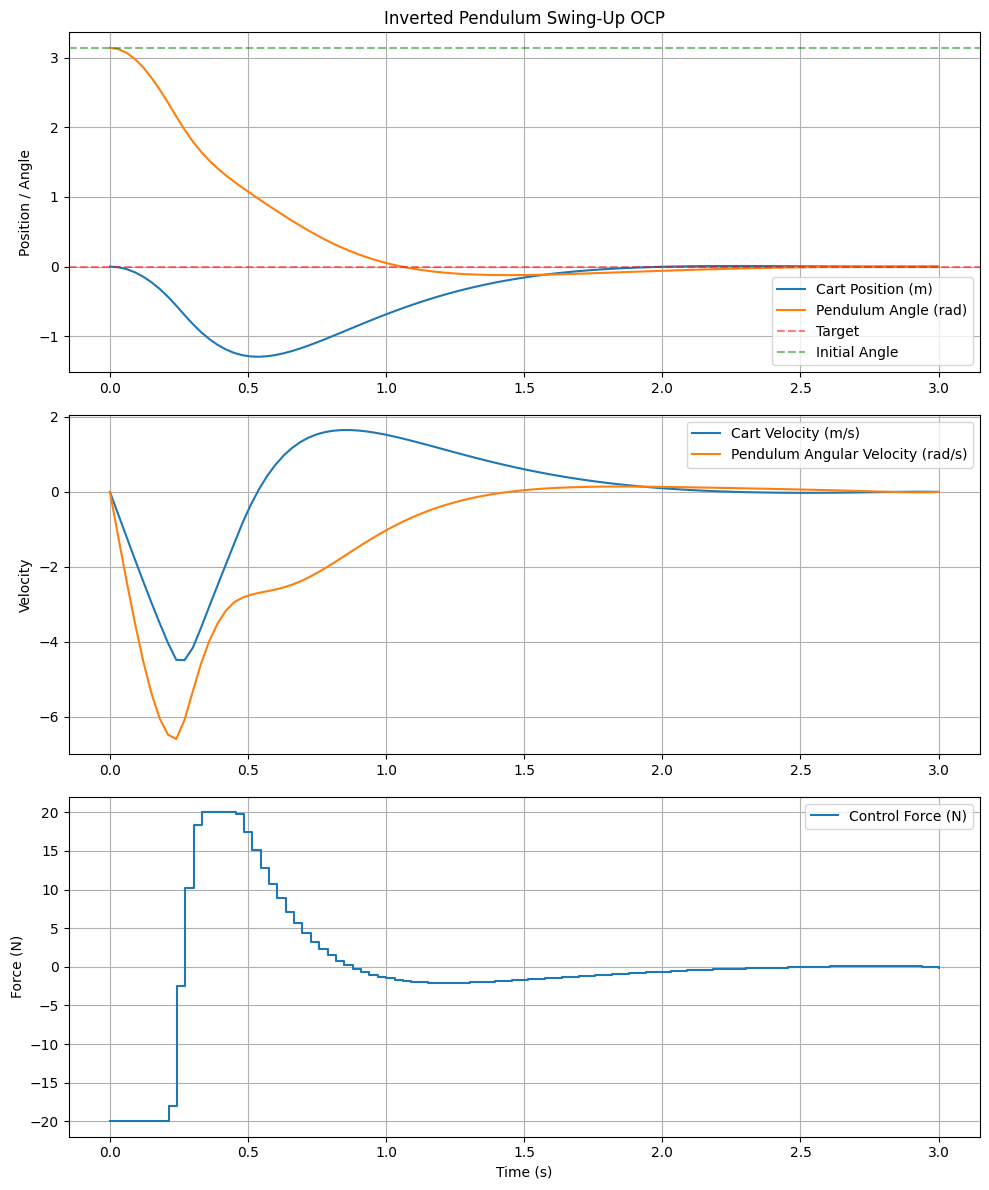

In [6]:
t_grid = np.linspace(0, T, N+1)
t_grid_u = np.linspace(0, T, N)

fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# Plot states
axs[0].plot(t_grid, X_opt[0, :], label='Cart Position (m)')
axs[0].plot(t_grid, X_opt[1, :], label='Pendulum Angle (rad)')
axs[0].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Target')
axs[0].axhline(y=np.pi, color='g', linestyle='--', alpha=0.5, label='Initial Angle')
axs[0].set_ylabel('Position / Angle')
axs[0].set_title('Inverted Pendulum Swing-Up OCP')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t_grid, X_opt[2, :], label='Cart Velocity (m/s)')
axs[1].plot(t_grid, X_opt[3, :], label='Pendulum Angular Velocity (rad/s)')
axs[1].set_ylabel('Velocity')
axs[1].legend()
axs[1].grid(True)

# Plot controls
axs[2].step(t_grid_u, U_opt, where='post', label='Control Force (N)')
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('Force (N)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()